In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test



In [2]:
df = pd.read_csv("../data/subscription_churn.csv")
df.head()
df.describe()
df["churned"].value_counts(normalize=True)

churned
1    0.5045
0    0.4955
Name: proportion, dtype: float64

In [3]:
df

,subscriber_id,signup_cohort_month,plan,acquisition_channel,tenure_days,churned
0,1,2023-04,pro,paid,269.8,1
1,2,2022-08,basic,organic,391.5,1
2,3,2023-11,pro,referral,200.0,0
3,4,2024-05,pro,organic,14.3,1
4,5,2022-11,basic,paid,408.1,1
...,...,...,...,...,...,...
3995,3996,2022-10,basic,organic,239.3,1
3996,3997,2024-04,basic,organic,34.7,1
3997,3998,2023-08,basic,paid,281.2,1
3998,3999,2022-10,basic,organic,146.4,1


## shape of the data

<Axes: xlabel='signup_cohort_month'>

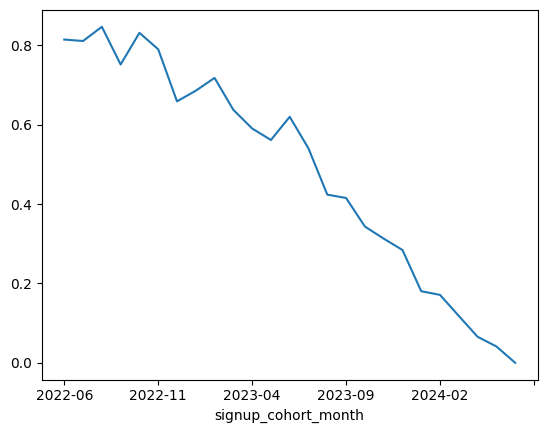

In [6]:
df.groupby('signup_cohort_month')['churned'].mean().plot()

In [7]:
kmf = KaplanMeierFitter()
kmf.fit(durations=df["tenure_days"], event_observed=df["churned"])

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 4000 total observations, 1982 right-censored observations>

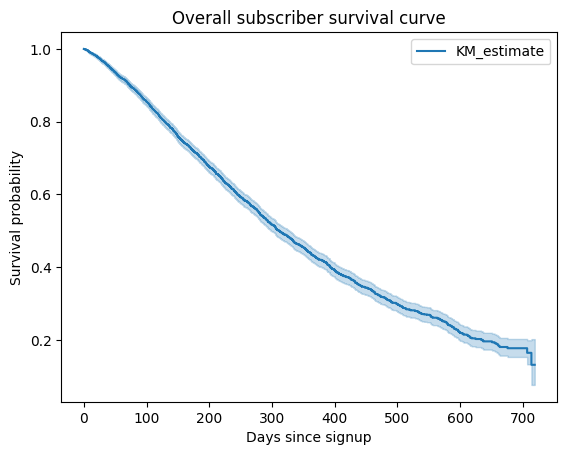

In [8]:
kmf.plot_survival_function()
plt.xlabel("Days since signup")
plt.ylabel("Survival probability")
plt.title("Overall subscriber survival curve")
plt.show()

In [9]:
print(kmf.median_survival_time_)
from lifelines.utils import median_survival_times
print(median_survival_times(kmf.confidence_interval_))


311.7
     KM_estimate_lower_0.95  KM_estimate_upper_0.95
0.5                   298.4                   327.9


## Step 3: Stratify by plan — KM curves + log-rank test (Q2)

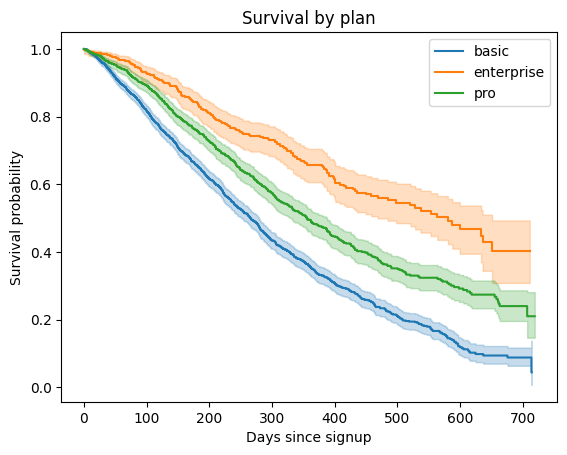

In [11]:
fig, ax = plt.subplots()
for plan_name, group in df.groupby("plan"):
    kmf = KaplanMeierFitter()
    kmf.fit(group["tenure_days"], group["churned"], label=plan_name)
    kmf.plot_survival_function(ax=ax)

plt.xlabel("Days since signup")
plt.ylabel("Survival probability")
plt.title("Survival by plan")
plt.show()

In [12]:
# significance across all 3 groups at once
results = multivariate_logrank_test(df["tenure_days"], df["plan"], df["churned"])
results.print_summary()

In [18]:
cph_df = df.copy()

cph_df["signup_cohort_month"] = pd.to_datetime(cph_df["signup_cohort_month"])
cph_df["cohort_index"] = (
    (cph_df["signup_cohort_month"].dt.year - cph_df["signup_cohort_month"].dt.year.min()) * 12
    + cph_df["signup_cohort_month"].dt.month
)

cph_df = pd.get_dummies(cph_df, columns=["plan", "acquisition_channel"], drop_first=True)
cph_df = cph_df.drop(columns=["subscriber_id", "signup_cohort_month"])

cph = CoxPHFitter()
cph.fit(cph_df, duration_col="tenure_days", event_col="churned")
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 4000 total observations, 1982 right-censored observations>
             duration col = 'tenure_days'
                event col = 'churned'
      baseline estimation = breslow
   number of observations = 4000
number of events observed = 2018
   partial log-likelihood = -14873.45
         time fit was run = 2026-07-29 15:17:32 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
cohort_index                 -0.00      1.00      0.00           -0.01            0.01                0.99                1.01
plan_enterprise              -0.99      0.37      0.08           -1.15           -0.83                0.32                0.44
plan_pro                     -0.43      0.65      0.05           -0.53           -0.34                0.59                0.71
acquisition_channel_paid      0.42      1.52      0.05            0.32            0.51                1.38                1.67
acquisition_channel_referral -0.32      0.73      0.07           -0.45           -0.19                0.64                0.83

                              cmp to      z      p  -log2(p)
covariate                                                   
cohort_index                    0.00  -0.01   0.99      0.01
plan_enterprise                 0.00 -11.93 <0.005    106.54
plan_pro                        0.00  -8.63 <0.005     57.23
acquisition_channel_paid        0.00   8.61 <0.005     56.95
acquisition_channel_referral    0.00  -4.81 <0.005     19.34
---
Concordance = 0.61
Partial AIC = 29756.91
log-likelihood ratio test = 333.59 on 5 df
-log2(p) of ll-ratio test = 229.96

In [20]:
check_assumptions() 

NameError: name 'check_assumptions' is not defined


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.5111)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5531)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6791)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5604)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8407)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5880)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0743)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0935)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8395)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9565)'>]]

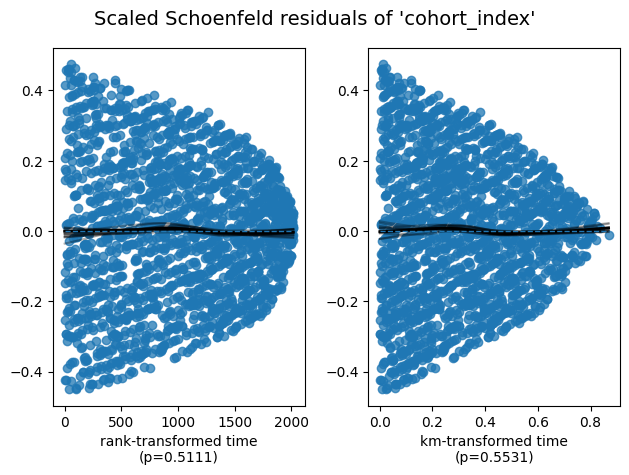

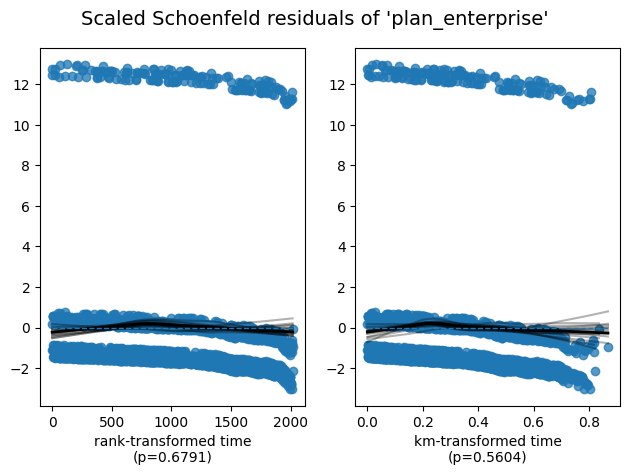

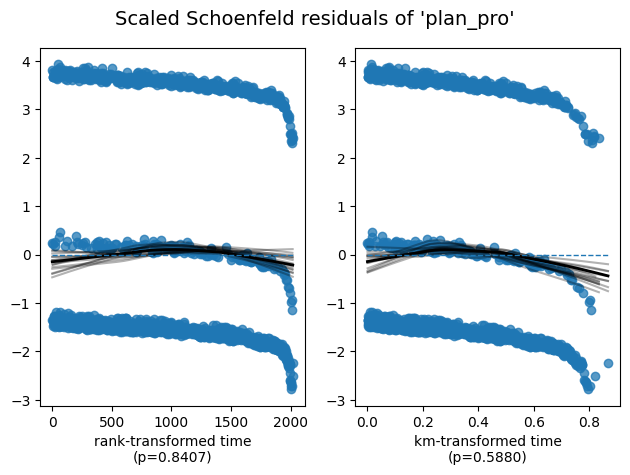

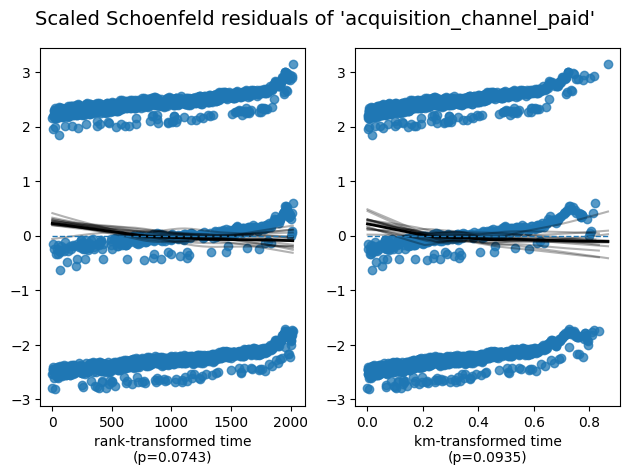

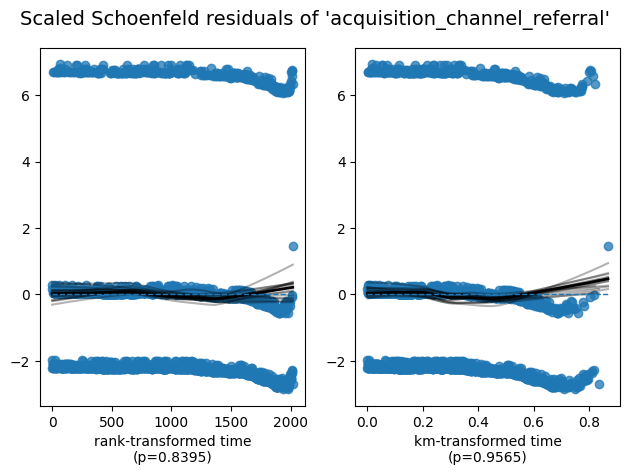

In [19]:
cph.check_assumptions(cph_df, p_value_threshold=0.05, show_plots=True)

## Step 6: Q5 — quantify the naive-average bias

In [22]:
from lifelines.utils import restricted_mean_survival_time

tau = df["tenure_days"].max()
km_rmst = restricted_mean_survival_time(kmf, t=tau)
print("KM restricted mean survival time (tau=%.1f):" % tau, km_rmst)

bias = naive_mean - km_rmst
pct_bias = bias / km_rmst * 100
print(f"Naive estimate is off by {bias:.1f} days ({pct_bias:.1f}%)")

KM restricted mean survival time (tau=719.0): 393.5715940196929
Naive estimate is off by -184.2 days (-46.8%)


## Summary

**Q1 — Overall Kaplan-Meier survival curve.** Median subscriber lifetime is **311.7 days** (95% CI: 298.4–327.9 days), based on 4,000 subscribers with a ~49.5% censoring rate (still active at window close).

**Q2 — Stratified by plan.** Survival clearly differs by plan (enterprise > pro > basic, as expected). A multivariate log-rank test across the three groups gives a test statistic of 176.06 (df=2, p < 0.005) — the differences are highly statistically significant.

**Q3 — Cox proportional hazards model.** Fit with `plan`, `acquisition_channel`, and `signup_cohort_month` (as a numeric cohort index) as covariates. Hazard ratios:

| covariate | hazard ratio | interpretation |
|---|---|---|
| `plan_enterprise` | 0.37 | 63% lower churn hazard vs. basic |
| `plan_pro` | 0.65 | 35% lower churn hazard vs. basic |
| `acquisition_channel_paid` | 1.52 | 52% higher churn hazard vs. organic |
| `acquisition_channel_referral` | 0.73 | 27% lower churn hazard vs. organic |
| `cohort_index` | 1.00 (p=0.99) | no meaningful trend over signup cohort |

All effects are highly significant (p < 0.005) except cohort trend, which is correctly null.

**Q4 — Proportional hazards assumption check.** `check_assumptions` reports the PH assumption **looks okay** for all covariates — no rank- or KM-transformed time test comes close to the p=0.05 threshold (closest is `acquisition_channel_paid` at ~0.07–0.09). No stratification or time-varying terms needed here.

**Q5 — Naive vs. KM-based lifetime estimate.** The naive "average tenure of churned users only" gives **209.4 days**, versus the censoring-aware KM restricted mean of **393.6 days** (tau = 719 days). That's a **184-day (46.8%) underestimate** — filtering to churned-only systematically excludes the longest-lived (still-active, censored) subscribers, and this bias is compounded by recent signup cohorts being heavily censored simply because they haven't had time to churn yet.

**Takeaway:** ignoring censoring doesn't just add noise — it introduces a large, systematic downward bias in subscriber lifetime estimates. The KM/Cox approach recovers the true underlying structure (plan and channel effects, roughly proportional hazards, no spurious cohort trend), matching how the dataset was generated.
